In [ ]:
import pandahouse
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import hashlib # Делать хеши
import swifter # Ускорялка метода apply
from scipy import stats # Статистика
from scipy.stats import norm, ttest_ind
%matplotlib inline

In [63]:
rng = np.random.default_rng()

In [64]:
connection = {
    'host' : 'http://clickhouse.lab.karpov.courses:8123',
    'password' : 'dpo_python_2020',
    'user' : 'student',
    'database' : 'simulator_20260320'
}

### Задача 1
К нам пришли наши коллеги из ML-отдела и рассказали, что планируют выкатывать новый алгоритм, рекомендующий нашим пользователям интересные посты. После обсуждений того, как он это делает, вы пришли к следующему пониманию: <br>

Алгоритм добавляет пользователям 1-2 просмотра<br>
Вероятность того, что он сработает, составляет 90%<br>
Если у пользователя меньше 50 просмотров, то алгоритм не сработает<br><br>
Вы предполагаете, что увеличение числа просмотров приведёт и к увеличению лайков на пользователя. Встаёт вопрос: сможем ли мы обнаружить различия в среднем количестве лайков на пользователя? Чтобы ответить на этот вопрос, давайте проведём симуляцию Монте-Карло!

Что мы будем делать:<br>

1) Построим на основе периода АА-теста распределения для генерации просмотров и CTR. Выгрузим данные запросами целиком.<br>
2) На эксперимент нам выделили неделю. Мы планируем разбивать пользователей на две группы в соотношении 50/50. Посчитайте, сколько пользователей в таком случае придётся на одну группу. <br>
3) Эффект алгоритма на просмотры мы сымитируем следующим образом: group_B_views + ((1 + np.binomial(n=1, p=0.5, size=размер_выборки)) * np.binomial(n=1, p=0.9, size=размер_выборки) * (group_B_views >= 50)).
4) Количество симуляций задайте не меньше 20000. Если хотите ещё больше уверенности в своих результатах — можете увеличить их число.
5) Лайки мы будем сравнивать t-тестом с поправкой Уэлча на неравные дисперсии (equal_var=False). Уровень значимости по классике поставим 0.05.
6) В ответе укажите получившееся значение мощности в процентах до первого знака после точки. Например, если у вас получится мощность, равная 0.919, то в ответе укажите 91.9.

1) Берём данные АА-теста из следующего диапазона: с '2026-02-20' по '2026-02-26'

In [65]:
q = """
SELECT
    views, count() as users
FROM (select 
    user_id,
    sum(action = 'view') as views
FROM {db}.feed_actions
where toDate(time) between '2026-02-20' and '2026-02-26'
group by user_id
)
group by views
order by views
"""


views_distribution = pandahouse.read_clickhouse(q, connection=connection)
views_distribution

,views,users
0,1,4
1,2,1
2,3,4
3,4,5
4,5,18
...,...,...
296,324,1
297,326,1
298,355,1
299,364,1


2. Подсчитаем количества пользователей

In [66]:
print(views_distribution.users.sum(),'всего пользователей',views_distribution.users.sum()/2, 'пользователей на группу')
N=views_distribution.users.sum()//2 #запишем размер выборки в переменную

41997 всего пользователей 20998.5 пользователей на группу


3. Эффект алгоритма на просмотры <br> group_B_views + ((1 + np.binomial(n=1, p=0.5, size=размер_выборки)) * np.binomial(n=1, p=0.9, size=размер_выборки) * (group_B_views >= 50))<br>
<br> Этот код модифицирует массив group_B_views (предположительно, просмотры группы B в A/B-тесте), добавляя случайные приросты только для элементов >= 50<br> 
Код состоит из базового массива плюс произведение трех компонентов:
1) 1 + np.binomial(n=1, p=0.5, size=размер_выборки) — генерирует 1 (с вероятн. 0.5) или 2 (с вероятн. 0.5) для каждого элемента добавляет 1-2 просмотра<br>
2) np.binomial(n=1, p=0.9, size=размер_выборки) — генерирует 0 (вероятн. 0.1) или 1 (вероятн. 0.9) вероятность того, что он сработает<br>
3) (group_B_views >= 50) — булева маска (True=1 для просмотров >=50, иначе 0) сработает тольок, если у пользователя > 50 просмотров<br>

Итоговый множитель: с вероятностью ~45% (0.5×0.9) добавляется +1 или +2, только если group_B_views[i] >= 50.<br> 

4. Проведём моделированием Монте-Карло. Количество симуляций задайте не меньше 20000. <br>
сгенерируем распределение просмотров, CTR, реализацию лайков.

In [67]:
views_distribution['p'] = views_distribution['users']/views_distribution.users.sum() # нормируем, получаем вероятностное распределение

In [68]:
views_distr = stats.rv_discrete(name='views_distr', 
                                values=(views_distribution['views'], 
                                        views_distribution['p'])) # сделаем дискретное распределение

<Axes: ylabel='Count'>

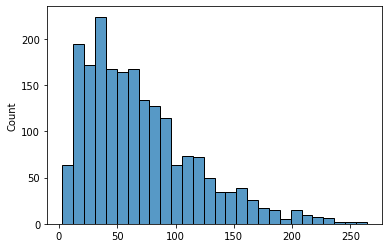

In [69]:
sns.histplot(views_distr.rvs(size=2000))

<Axes: ylabel='Count'>

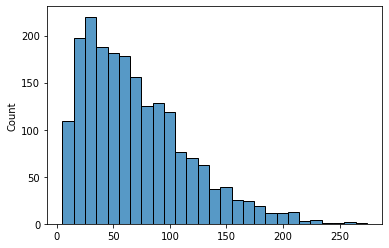

In [70]:
#создаём распределение на основе реальных данных
#rng.choice(значения_метрики, size=(количество_симуляций, размер_выборки), 
         #  replace=True, p=относительные_частоты)
sns.histplot(rng.choice(views_distribution['views'], size=(2000), 
           replace=True, p=views_distribution['p']))

In [ ]:
#в качестве примера сгенерируем данные из биномиального распределения
#параметры n, p, size можете задать самостоятельно
#в scipy это будет примерно так
scipy.stats.binom.rvs(n, p, size)
#а в numpy так
rng.binomial(n, p, size)

#создаём генератор распределения на основе реальных данных
distr = scipy.stats.rv_discrete(values=(значения_метрики, относительные_частоты))
#симулируем выборки определённого размера несколько раз
distr.rvs(size=(количество_симуляций, размер_выборки))

# А лучше вот так- и для дробных занчений CTR
rng.choice(значения_метрики, size=(количество_симуляций, размер_выборки), 
           replace=True, p=относительные_частоты)

#симуляции биномиального распределения через двухмерный массив
rng.binomial(n, p, size=(количество_симуляций, размер_выборки))

#они же через цикл. ИСПОЛЬЗОВАТЬ ЦИКЛ
for _ in range(количество_симуляций):
   rng.binomial(n, p, size=размер_выборки)

#ОТСЛЕЖИВАЕМ ПРОГРЕСС
from tqdm import tqdm

for _ in tqdm(range(количество_симуляций)):
   rng.binomial(n, p, size=размер_выборки)

In [71]:
#выгружаю распределение CTR на даты AA-теста
q = """
select 
   floor(ctr, 2) as ctr, count() as users
from (select toDate(time) as dt, 
    user_id,
    sum(action = 'like')/sum(action = 'view') as ctr
FROM {db}.feed_actions
where dt between '2026-02-20' and '2026-02-26'
group by dt, user_id
)
group by ctr
"""


ctr_distribution = pandahouse.read_clickhouse(q, connection=connection) #достанем распределение cTR за эту неделю
ctr_distribution['p'] = ctr_distribution['users']/ctr_distribution.users.sum()

In [72]:
ctr_distribution

,ctr,users,p
0,0.00,1443,0.016952
1,0.65,4,0.000047
2,0.71,5,0.000059
3,0.49,4,0.000047
4,0.54,72,0.000846
...,...,...,...
75,0.52,86,0.001010
76,0.15,3852,0.045253
77,0.44,271,0.003184
78,0.60,64,0.000752


In [73]:
#from tqdm import tqdm
#количество симуляций 20000
#размер выборки N=20998
p_values=[]

for _ in tqdm(range(20000)):
    group_A_views = rng.choice(views_distribution['views'], size=N, replace=True, p=views_distribution['p']).astype("int32")
    group_B_views = rng.choice(views_distribution['views'], size=N, replace=True, p=views_distribution['p']).astype("int32")
    group_B_views2 = group_B_views + ((1 + rng.binomial(1, 0.5, N)) * rng.binomial(1, 0.9, N) * (group_B_views >= 50)) #новый эффект
    
    group_A_ctr = rng.choice(ctr_distribution['ctr'], size=N, replace=True, p=ctr_distribution['p'])
    group_B_ctr = rng.choice(ctr_distribution['ctr'], size=N, replace=True, p=ctr_distribution['p'])
    likes_A = rng.binomial(group_A_views, group_A_ctr)
    likes_B = rng.binomial(group_B_views2, group_B_ctr)
    p_values.append(stats.ttest_ind(likes_A, likes_B, equal_var=False).pvalue < 0.05)
_1_minus_beta= (sum(p_values)/ 20000)*100
print(_1_minus_beta)

  1%|▏         | 262/20000 [00:03<04:27, 73.84it/s]


KeyboardInterrupt: 

#### Задача 2
К нам снова пришли коллеги из ML-отдела с радостной новостью: они улучшили качество алгоритма! Теперь он срабатывает на пользователях с числом просмотров от 30 и выше.

In [80]:
from tqdm import tqdm
#количество симуляций 20000
#размер выборки N=20998
p_values=[]

for _ in tqdm(range(20000)):
    group_A_views = rng.choice(views_distribution['views'], size=N, replace=True, p=views_distribution['p']).astype("int32")
    group_B_views = rng.choice(views_distribution['views'], size=N, replace=True, p=views_distribution['p']).astype("int32")
    group_B_views2 = group_B_views + ((1 + rng.binomial(1, 0.5, N)) * rng.binomial(1, 0.9, N) * (group_B_views >= 30)) #новый эффект
    
    group_A_ctr = rng.choice(ctr_distribution['ctr'], size=N, replace=True, p=ctr_distribution['p'])
    group_B_ctr = rng.choice(ctr_distribution['ctr'], size=N, replace=True, p=ctr_distribution['p'])
    likes_A = rng.binomial(group_A_views, group_A_ctr)
    likes_B = rng.binomial(group_B_views2, group_B_ctr)
    p_values.append(stats.ttest_ind(likes_A, likes_B, equal_var=False).pvalue < 0.05)
_1_minus_beta= (sum(p_values)/ 20000)*100
print(_1_minus_beta)

  2%|▏         | 303/20000 [00:04<04:21, 75.27it/s]


KeyboardInterrupt: 

#### Задача 3
Теперь нас пришло радовать начальство: нам утвердили длительность эксперимента длиной в 2 недели! Давайте теперь допустим, что в эти две недели к нам придёт столько же пользователей, сколько пришло суммарно за период АА-теста и АБ-теста (опять же, смотрите диапазон дат в прошлом уроке).

Подкорректируйте размер группы соответствующим образом. Сами распределения, на основе которых мы симулируем данные, менять не будем.

даты АА теста '2026-02-20' and '2026-02-26' <br>
даты АБ теста '2026-02-27' and '2026-03-05'

#выгружаю новые данные
q_v_2_weeks = """
SELECT
    views, count() as users
FROM (select 
    user_id,
    sum(action = 'view') as views
FROM {db}.feed_actions
where toDate(time) between '2026-02-20' and '2026-03-05'
group by user_id
)
group by views
order by views
"""


views_distribution_2_weeks = pandahouse.read_clickhouse(q_v_2_weeks, connection=connection)
views_distribution_2_weeks['p'] = views_distribution_2_weeks['users']/views_distribution_2_weeks.users.sum()
views_distribution_2_weeks

In [32]:
print(views_distribution_2_weeks.users.sum(),'всего пользователей',views_distribution_2_weeks.users.sum()/2, 'пользователей на группу')
N_2_weeks=views_distribution_2_weeks.users.sum()//2 #запишем размер выборки в переменную

61182 всего пользователей 30591.0 пользователей на группу


#создаём распределение на основе реальных данных
#rng.choice(значения_метрики, size=(количество_симуляций, размер_выборки), 
         #  replace=True, p=относительные_частоты)
sns.histplot(rng.choice(views_distribution_2_weeks['views'], size=(2000), 
           replace=True, p=views_distribution_2_weeks['p']))

#выгружаю распределение CTR на даты AA-теста
q_c_2_weeks = """
select 
   floor(ctr, 2) as ctr, count() as users
from (select toDate(time) as dt, 
    user_id,
    sum(action = 'like')/sum(action = 'view') as ctr
FROM {db}.feed_actions
where dt between '2026-02-20' and '2026-03-05'
group by dt, user_id
)
group by ctr
"""


ctr_distribution_2_weeks = pandahouse.read_clickhouse(q_c_2_weeks, connection=connection) #достанем распределение cTR за 2 недели
ctr_distribution_2_weeks['p'] = ctr_distribution_2_weeks['users']/ctr_distribution_2_weeks.users.sum()
ctr_distribution_2_weeks

ctr_distribution_2_weeks['p'].max()

In [92]:
from tqdm import tqdm
#количество симуляций 20000
#размер выборки 
N_2_weeks
p_values=[]

for _ in tqdm(range(20000)):
    group_A_views = rng.choice(views_distribution['views'], size=N_2_weeks, replace=True, p=views_distribution['p']).astype("int32")
    group_B_views = rng.choice(views_distribution['views'], size=N_2_weeks, replace=True, p=views_distribution['p']).astype("int32")
    group_B_views2 = group_B_views + ((1 + rng.binomial(1, 0.5, N_2_weeks)) * rng.binomial(1, 0.9, N_2_weeks) * (group_B_views >= 30)) #новый эффект
    
    group_A_ctr = rng.choice(ctr_distribution['ctr'], size=N_2_weeks, replace=True, p=ctr_distribution['p'])
    group_B_ctr = rng.choice(ctr_distribution['ctr'], size=N_2_weeks, replace=True, p=ctr_distribution['p'])
    likes_A = rng.binomial(group_A_views, group_A_ctr)
    likes_B = rng.binomial(group_B_views2, group_B_ctr)
    p_values.append(stats.ttest_ind(likes_A, likes_B, equal_var=False).pvalue < 0.05)
_1_minus_beta= (sum(p_values)/ 20000)*100
print(_1_minus_beta)

100%|██████████| 20000/20000 [06:13<00:00, 53.56it/s]

56.165


#### Задача 4
Всё это время мы анализировали наши выборки целиком — и тех пользователей, на которых алгоритм повлиял, и тех, кого он не мог затронуть (меньше 30 просмотров).
А что, если мы будем отбирать только нужных пользователей и скармливать t-тесту именно их? 
Да, выборка будет меньше, но мы избавимся от мусора — а значит, и чувствительность наверняка будет выше.
можем отсеять их примерно таким образом:

(здесь мы симулируем данные просмотров, CTR и лайков)

mask_A = group_A_views >= 30 <br>
mask_B = group_B_views >= 30 <br>

scipy.stats.ttest_ind(group_A_likes[mask_A], group_B_likes[mask_B], equal_var=False)

In [103]:
from tqdm import tqdm
#количество симуляций 20000
#размер выборки 
N_2_weeks
p_values=[]

for _ in tqdm(range(20000)):
    group_A_views = rng.choice(views_distribution['views'], size=N_2_weeks, replace=True, p=views_distribution['p']).astype("int32")
    group_B_views = rng.choice(views_distribution['views'], size=N_2_weeks, replace=True, p=views_distribution['p']).astype("int32")
    group_B_views2 = group_B_views + ((1 + rng.binomial(1, 0.5, N_2_weeks)) * rng.binomial(1, 0.9, N_2_weeks) * (group_B_views >= 30)) #новый эффект
    
    group_A_ctr = rng.choice(ctr_distribution['ctr'], size=N_2_weeks, replace=True, p=ctr_distribution['p'])
    group_B_ctr = rng.choice(ctr_distribution['ctr'], size=N_2_weeks, replace=True, p=ctr_distribution['p'])
    likes_A = rng.binomial(group_A_views, group_A_ctr)
    likes_B = rng.binomial(group_B_views2, group_B_ctr)
    mask_A = group_A_views >= 30
    mask_B = group_B_views >= 30
    p_values.append(stats.ttest_ind(likes_A[mask_A], likes_B[mask_B], equal_var=False).pvalue < 0.05) 
_1_minus_beta= (sum(p_values)/ 20000)*100
print(_1_minus_beta)

100%|██████████| 20000/20000 [06:21<00:00, 52.42it/s]

64.41


In [101]:
mask_A

array([ True,  True, False, ...,  True, False,  True])

In [90]:
g=  rng.choice(ctr_distribution_2_weeks['ctr'], size=N_2_weeks, replace=True, p=ctr_distribution_2_weeks['p'])
print(g[g>1], g[g<0], g[np.isnan(g)])

[inf] [] []


In [ ]:
rng.binomial(n, p, size=(количество_симуляций, размер_выборки))

scipy.stats.binom.rvs(n, p, size)
#а в numpy так
rng.binomial(n, p, size)

In [20]:
tqdm

<module 'tqdm' from '/opt/conda/lib/python3.8/site-packages/tqdm/__init__.py'>

In [14]:
#создаём распределение на основе реальных данных
ctr_distr= rng.choice(ctr_distribution.ctr, size=(20000), replace=True, p=ctr_distribution.ctr)
sns.histplot(ctr_distr)

ValueError: probabilities do not sum to 1

In [ ]:
sns.histplot(rng.choice(views_distribution['views'], size=(2000), 
           replace=True, p=views_distribution['p']))

In [21]:
probabilities = ctr_distribution['p']
values = ctr_distribution['ctr']
distrib = stats.rv_discrete(values=(range(len(probabilities)), probabilities))

def get_ctrs(x, y, distrib, values):
    idx = distrib.rvs(size=x*y)
    result = values[idx]
    return np.array(result).reshape(x,y)


In [ ]:
group_A_views = views_distr.rvs(size = (20000, 20000)).astype("int32")
group_B_views = views_distr.rvs(size = (20000, 20000)).astype("int32")
group_A_ctr = group_B_views + ((1 + np.binomial(n=1, p=0.5, size=20000)) * np.binomial(n=1, p=0.9, size=20000) * (group_B_views >= 50)) #новый эффект 
group_B_ctr = get_ctrs(20000,20000, distrib, values)
#clicks_A = stats.binom.rvs(group_A_views, group_A_ctr)
#clicks_B = stats.binom.rvs(group_B_views, group_B_ctr)

In [ ]:
rng.choice(значения_метрики, size=(количество_симуляций, размер_выборки), 
           replace=True, p=относительные_частоты)

In [ ]:
def t_test(a, b):
    """
    Считает p-value для t-теста с двусторонней альтернативой 
    :param a: np.array вида (n_experiments, n_users), значения метрик в контрольных группах
    :param b: np.array вида (n_experiments, n_users), значения метрик в тестовых группах
    :return: np.array вида (n_experiments), посчитанные p-value t-теста для всего списка экспериментов
    """
    result = list(map(lambda x: stats.ttest_ind(
        x[0], x[1], equal_var=False).pvalue, zip(a, b)))
    return np.array(result)

In [ ]:
np.sum(t_test(clicks_A/group_A_views, clicks_B/group_B_views)<= 0.05)/2000